<a href="https://colab.research.google.com/github/Ibrahim-Ayaz/E-scooter-Lane-Detection-Object-Detection-Project/blob/main/e_scooter_lane_detection_project_pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-Scooter Lane Detection Workflow 🛴⚠️

In this notebook, we calculate the e-scooter’s lateral deviation from the road curb using a pretrained TensorFlow Hub model. The final stage of the project visualizes the deviation analysis through a time-based graph and exports the computed results to a CSV file for further experimentation and prototyping.

The workflow will cover the following necessary steps:
  * Setting up environmental dynamics for this Colab environment for our project to run successfully without facing any bugs.
  * Upload a training video sample from our PC/desktop.
  * Pass the training video sample to our pretrained object detector that we we will get from TensorFlow's Hub library.
  * Create a frames feature extraction function to **feature-extract** the most important representations for our model to generalise well on.
  * Preprocess the frames for computing the required distance (d)
  * Plot the model's performance, which is the distance it obtained with respect to each timestep of the training video sample.

  For checking out TensorFlow's Hub library, refer to the following link: https://www.tensorflow.org/hub

In [ ]:
# 1️⃣ Setup environment dynamics for our Colab environment
!pip uninstall -y tensorflow-io tensorflow-io-gcs-filesystem
!pip install -q tensorflow==2.15.0 tensorflow-hub==0.16.1 tensorflow-addons==0.22.0 pandas matplotlib tqdm
!pip install -q tensorflow-io==0.31.0 tensorflow-io-gcs-filesystem==0.31.0

import tensorflow as tf, tensorflow_hub as hub
try:
    import tensorflow_io as tfio
except ImportError:
    # Safe fallback for environments where tfio still fails
    print("⚠️ tensorflow-io failed to load — using alt video extraction path.")
    tfio = None

from google.colab import drive, files
from tqdm import tqdm
import pandas as pd, numpy as np, os, matplotlib.pyplot as plt

drive.mount('/content/drive')
out_dir = '/content/drive/MyDrive/e_scooter_output'
os.makedirs(out_dir, exist_ok=True)

device = 'GPU' if tf.config.list_physical_devices('GPU') else 'CPU'
print(f'✅ TensorFlow {tf.__version__} on {device}')
if tfio:
    print(f'✅ TensorFlow-IO {tfio.__version__} loaded successfully')
else:
    print('⚠️ TensorFlow-IO unavailable — fallback decoding will be used.')
print('📂 Output directory:', out_dir)

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.15.0
ERROR: Ignored the following versions that require a different python version: 0.37.0 Requires-Python <3.12,>=3.7
ERROR: Could not find a version that satisfies the requirement tensorflow-io==0.31.0 (from versions: 0.37.1)
ERROR: No matching distribution found for tensorflow-io==0.31.0
⚠️ tensorflow-io failed to load — using alt video extraction path.
Mounted at /content/drive
✅ TensorFlow 2.19.0 on GPU
⚠️ TensorFlow-IO unavailable — fallback decoding will be used.
📂 Output directory: /content/drive/MyDrive/e_scooter_output


In [ ]:
# 2️⃣ Upload a training video sample
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print('🎞️ Video uploaded:', video_path)

Saving WhatsApp Video 2025-10-15 at 11.38.42.mp4 to WhatsApp Video 2025-10-15 at 11.38.42.mp4
🎞️ Video uploaded: WhatsApp Video 2025-10-15 at 11.38.42.mp4


In [ ]:
# 3️⃣ Load pretrained EfficientDet-D2 model from TensorFlow Hub
import tensorflow as tf
import tensorflow_hub as hub

# Load EfficientDet-D2 directly from TF Hub
MODEL_URL = "https://tfhub.dev/tensorflow/efficientdet/d2/1"
detector = hub.load(MODEL_URL)

print("✅ EfficientDet-D2 model loaded successfully from TensorFlow Hub!")

✅ EfficientDet-D2 model loaded successfully from TensorFlow Hub!


In [ ]:
# 4️⃣ Create feature-extraction function to capture important representation for a training video sample
import subprocess, imageio.v3 as iio
import numpy as np, tensorflow as tf

def extract_frames(path, max_frames=None):
    """
    Robust frame extraction that works in all Colab environments.
    Uses FFmpeg via imageio backend (no TensorFlow-IO dependency).
    Returns a 4D float32 tensor [frames, height, width, 3].
    """
    try:
        frames = iio.imread(path, plugin="pyav")  # fast and stable
    except Exception:
        # absolute fallback to ffmpeg command
        tmp_dir = "/tmp/frames"
        subprocess.run(["mkdir", "-p", tmp_dir])
        subprocess.run([
            "ffmpeg", "-i", path, "-vf", "scale=512:512",
            f"{tmp_dir}/frame_%04d.jpg"
        ])
        import glob
        imgs = sorted(glob.glob(f"{tmp_dir}/frame_*.jpg"))
        frames = np.stack([iio.imread(f) for f in imgs])
    if max_frames:
        frames = frames[:max_frames]
    frames = tf.convert_to_tensor(frames, dtype=tf.float32) / 255.0
    print(f"✅ Extracted {frames.shape[0]} frames, size {frames.shape[1]}×{frames.shape[2]}")
    return frames

In [ ]:
# 5️⃣ Process frames & compute distance (TF-OD-API model)
import pandas as pd
from tqdm import tqdm
import tensorflow as tf, os

px_to_m = 0.015
distances = []

try:
    _ = video.shape
except NameError:
    print("⚠️ 'video' not found – extracting frames …")
    video = extract_frames(video_path)

detect_fn = detector.signatures["serving_default"]

print(f"🎞️ Processing {video.shape[0]} frames …")
for i in tqdm(range(video.shape[0])):
    frame = tf.image.resize(video[i], (320, 320))
    frame_uint8 = tf.image.convert_image_dtype(frame, tf.uint8)
    input_tensor = tf.expand_dims(frame_uint8, 0)

    detections = detect_fn(input_tensor)
    boxes = detections["detection_boxes"][0].numpy()
    scores = detections["detection_scores"][0].numpy()

    if len(scores) > 0 and scores[0] > 0.3:
        ymin, xmin, ymax, xmax = boxes[0]
        center_x = (xmin + xmax) / 2.0
        deviation_px = abs(center_x - 0.5) * 320
        distance_m = deviation_px * px_to_m
    else:
        distance_m = 0.0
    distances.append(distance_m)

csv_path = os.path.join(out_dir, "scooter_lane_distances.csv")
pd.DataFrame(distances, columns=["distance_m"]).to_csv(csv_path, index=False)
print("✅ Saved distances to", csv_path)

⚠️ 'video' not found – extracting frames …
✅ Extracted 831 frames, size 512×512
🎞️ Processing 831 frames …


100%|██████████| 831/831 [01:40<00:00,  8.27it/s]

✅ Saved distances to /content/drive/MyDrive/e_scooter_output/scooter_lane_distances.csv


✅ Loaded 831 distances from CSV.


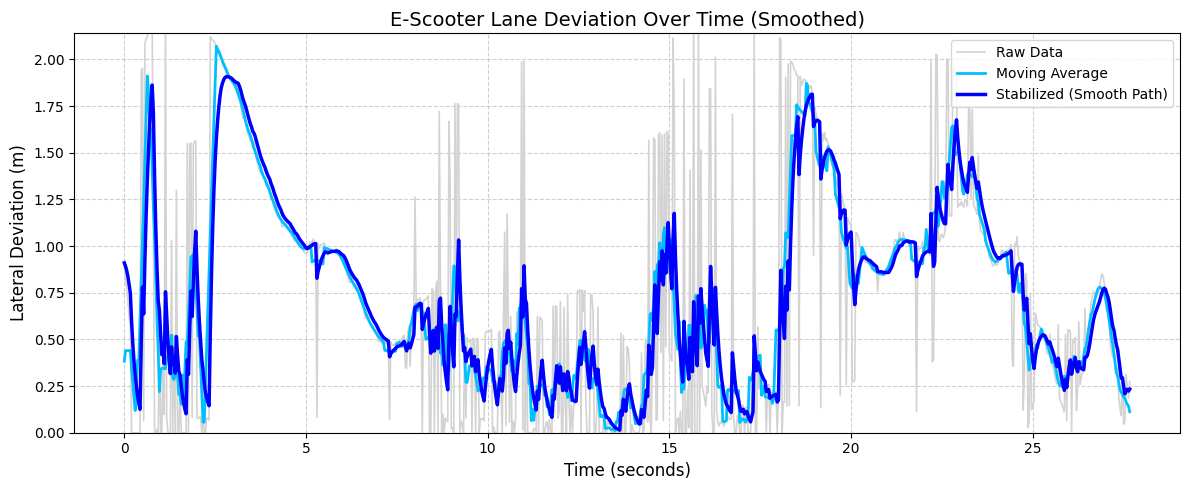

✅ Smoothed plot saved to: /content/drive/MyDrive/e_scooter_output/lane_deviation_plot_smoothed.png
ℹ️ Y-axis scaled to 0.00–2.14 m


<Figure size 640x480 with 0 Axes>

In [ ]:
# 6️⃣ Plot model results and save them in Google Drive
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

csv_path = os.path.join(out_dir, "scooter_lane_distances.csv")

try:
    data = pd.read_csv(csv_path)
    distances = data["distance_m"].dropna().to_numpy()
    print(f"✅ Loaded {len(distances)} distances from CSV.")
except Exception as e:
    print("⚠️ Could not load distances from CSV:", e)
    distances = np.array([])

if len(distances) > 0:
    FPS = 30  # set to your actual frame rate
    timesteps = np.arange(len(distances)) / FPS

    # --- Moving average smoother ---
    window_size = 10  # larger → smoother
    smooth_dist = np.convolve(distances, np.ones(window_size)/window_size, mode="same")

    # --- Kalman-like exponential smoothing ---
    alpha = 0.2  # lower → stronger smoothing
    kalman_like = np.zeros_like(distances)
    kalman_like[0] = distances[0]
    for i in range(1, len(distances)):
        kalman_like[i] = alpha * distances[i] + (1 - alpha) * kalman_like[i-1]

    # --- Dynamic y-axis bounds ---
    q1, q3 = np.percentile(distances, [5, 95])
    y_min = max(0, round(q1 - 0.1, 2))
    y_max = round(q3 + 0.2, 2)

    plt.figure(figsize=(12, 5))
    plt.plot(timesteps, distances, color="lightgray", linewidth=1.2, label="Raw Data")
    plt.plot(timesteps, smooth_dist, color="deepskyblue", linewidth=2, label="Moving Average")
    plt.plot(timesteps, kalman_like, color="blue", linewidth=2.5, label="Stabilized (Smooth Path)")

    plt.title("E-Scooter Lane Deviation Over Time (Smoothed)", fontsize=14)
    plt.xlabel("Time (seconds)", fontsize=12)
    plt.ylabel("Lateral Deviation (m)", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.ylim(y_min, y_max)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    plot_path = os.path.join(out_dir, "lane_deviation_plot_smoothed.png")
    plt.savefig(plot_path)
    print(f"✅ Smoothed plot saved to: {plot_path}")
    print(f"ℹ️ Y-axis scaled to {y_min:.2f}–{y_max:.2f} m")
else:
    print("⚠️ No distances to plot — check if frame processing loop ran correctly.")